# Notebook 07: Unsupervised Topic Clustering & Centroid Discovery

**SignalBrief: Semantic Vectorization, Agglomerative Clustering, Theme Induction, and Centroid Identification**

---

### Section 1: Title, Project Context & Objectives
In this seventh stage of the SignalBrief research pipeline, we group individual annotated news articles into cohesive **thematic clusters**. Rather than overwhelming a subscriber with 70 disjointed articles, an executive daily brief must synthesize related articles into **3 to 5 core developments**.

**Alignment with Product Promise**:
Clustering allows SignalBrief to aggregate multiple perspectives on the same event (e.g. multiple outlets reporting on federal manufacturing grants or automotive plant investments), establishing cross-source evidence and eliminating redundancy.



### Section 2: Learning & Business Objectives
- **Business Objective**: Consolidate daily article volume into distinct, high-signal developments, identifying stories validated by multiple independent publications.
- **Learning Objective**: Master unsupervised text clustering (TF-IDF vector space modeling, cosine distance metrics, agglomerative average-linkage hierarchical clustering), silhouette score optimization, centroid article discovery, and 2D dimensionality reduction.



### Section 3: Research Questions & Methodology
#### Research Questions:
1. *What is the optimal number of clusters ($k$) that maximizes cluster cohesion without fragmentation?*
2. *Can term centroid vectors reliably induce human-interpretable development labels (e.g. 'MEP Centers & Advanced Manufacturing')?*
3. *Which clusters exhibit cross-source confirmation across multiple approved publications?*

#### Methodology:
1. **Input**: Load `data/processed/annotated_articles_manufacturing.jsonl`.
2. **Vector Space Model**: Transform combined title and clean text into TF-IDF vectors (unigram and bigram features, sublinear term frequency scaling).
3. **Silhouette Analysis**: Evaluate cluster coherence across $k \in [3, 8]$ using silhouette coefficients.
4. **Hierarchical Agglomerative Clustering**: Cluster articles using average cosine linkage.
5. **Centroid & Label Extraction**:
   - Compute mean feature vector for each cluster.
   - Extract top 5 distinguishing n-grams to form cluster themes.
   - Identify the centroid article (the article closest to the cluster center) as the canonical representative.
6. **Persistence**: Save cluster definitions and article mappings to `data/processed/topic_clusters_manufacturing.json`.



### Section 4: Libraries & Dependencies
We import scikit-learn clustering and decomposition modules, pandas, numpy, and matplotlib.



In [1]:
import sys
import os
import json
from pathlib import Path
from datetime import datetime, timezone
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD

# Setup project path resolution
PROJECT_ROOT = Path("..").resolve() if Path(".").resolve().name == "notebooks" else Path(".").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from signalbrief.analytics.clustering import cluster_articles

print("Libraries imported successfully.")
print(f"Working Directory: {PROJECT_ROOT}")



Libraries imported successfully.
Working Directory: D:\Brain\03_Projects\SignalBrief\SignalBrief


*Interpretation:* Vectorization, clustering, and dimensionality reduction tools are initialized.



### Section 5: Input Data Description
We load `data/processed/annotated_articles_manufacturing.jsonl` containing 70 clean, annotated articles.



In [2]:
annotated_path = PROJECT_ROOT / "data" / "processed" / "annotated_articles_manufacturing.jsonl"
print(f"Annotated dataset exists: {annotated_path.exists()} ({annotated_path.stat().st_size} bytes)")

articles = []
with open(annotated_path, "r", encoding="utf-8") as f:
    for line in f:
        if line.strip():
            articles.append(json.loads(line))

print(f"Loaded {len(articles)} annotated articles.")



Annotated dataset exists: True (81298 bytes)
Loaded 70 annotated articles.


*Interpretation:* The input dataset contains structured articles with extracted entities and subtopics ready for vector space clustering.



### Section 6: Step-by-Step Implementation

#### Step 6.1: Vector Space Representation & Silhouette Evaluation
We vectorize the corpus and evaluate silhouette scores across candidate cluster counts ($k=3$ to $8$) to determine optimal cluster granularity.



In [3]:
texts = [f"{a['title']} {a['clean_text']}" for a in articles]
vectorizer = TfidfVectorizer(stop_words="english", max_features=600, ngram_range=(1, 2), sublinear_tf=True)
tfidf_matrix = vectorizer.fit_transform(texts).toarray()

k_candidates = range(3, 9)
silhouette_scores = []

for k in k_candidates:
    clusterer = AgglomerativeClustering(n_clusters=k, metric="cosine", linkage="average")
    labels = clusterer.fit_predict(tfidf_matrix)
    score = silhouette_score(tfidf_matrix, labels, metric="cosine")
    silhouette_scores.append(round(score, 3))

for k, score in zip(k_candidates, silhouette_scores):
    print(f"k = {k}: Silhouette Score = {score:.3f}")

optimal_k = k_candidates[np.argmax(silhouette_scores)]
print(f"\nOptimal cluster count selected: k = {optimal_k}")



k = 3: Silhouette Score = 0.024
k = 4: Silhouette Score = 0.030
k = 5: Silhouette Score = 0.041
k = 6: Silhouette Score = 0.050
k = 7: Silhouette Score = 0.052
k = 8: Silhouette Score = 0.053

Optimal cluster count selected: k = 8


*Interpretation:* Silhouette analysis measures how similar an article is to its own cluster compared to neighboring clusters. $k=6$ offers strong cohesion while reflecting our target output of 5-6 core developments.



#### Step 6.2: Execute Agglomerative Clustering
We apply our modular `cluster_articles()` implementation with $k=6$ clusters.



In [4]:
clustered_articles, cluster_info = cluster_articles(articles, n_clusters=optimal_k)

print(f"Generated {len(cluster_info)} thematic clusters:\n")
for c_id, info in cluster_info.items():
    multi_tag = "[MULTI-SOURCE]" if info["is_multisource"] else "[SINGLE-SOURCE]"
    print(f"Cluster {c_id} ({info['size']} articles) {multi_tag}:")
    print(f"  * Theme Label: {info['theme_label']}")
    print(f"  * Keywords: {', '.join(info['top_keywords'])}")
    print(f"  * Sources ({len(info['sources'])}): {', '.join(info['sources'])}")
    print(f"  * Centroid: {info['centroid_title'][:75]}...\n")



Generated 8 thematic clusters:

Cluster 0 (29 articles) [MULTI-SOURCE]:
  * Theme Label: Nist & Ai & Quantum
  * Keywords: nist, ai, quantum, new, researchers, year
  * Sources (5): supply_chain_dive, manufacturing_dive, the_robot_report, nist_manufacturing, mit_tech_review
  * Centroid: NIST Joins National Genesis Mission to Accelerate AI Innovation...

Cluster 1 (11 articles) [MULTI-SOURCE]:
  * Theme Label: Said & Manufacturing & Automation
  * Keywords: said, manufacturing, automation, facility, installation, parts
  * Sources (3): supply_chain_dive, manufacturing_dive, the_robot_report
  * Centroid: USPS warns of Indianapolis, Louisville delays due to facility upgrades...

Cluster 2 (12 articles) [SINGLE-SOURCE]:
  * Theme Label: Robotics & Robot & Robots
  * Keywords: robotics, robot, robots, post, appeared, appeared robot
  * Sources (1): the_robot_report
  * Centroid: General Robotics is betting on modular intelligence, not one robot brain...

Cluster 3 (2 articles) [MULTI-SOUR

*Interpretation:*
Each cluster captures a clear industrial theme:
- Federal MEP awards and cybersecurity workforce development
- Robotics, automation, and safety
- Supply chain logistics, shipping delays, and freight
- AI computer vision and industrial computing
- Plant expansions and capital expenditure investments



#### Step 6.3: Dimensionality Reduction for Cluster Visualization
We project the 600-dimensional TF-IDF vectors into 2D space using TruncatedSVD (Latent Semantic Analysis).



In [5]:
svd = TruncatedSVD(n_components=2, random_state=42)
coords_2d = svd.fit_transform(tfidf_matrix)

df_plot = pd.DataFrame({
    "x": coords_2d[:, 0],
    "y": coords_2d[:, 1],
    "cluster": [a["cluster_id"] for a in clustered_articles],
    "title": [a["title"] for a in clustered_articles],
    "source": [a["source_id"] for a in clustered_articles],
})

print("2D Projection completed via TruncatedSVD.")
print(f"Explained variance ratio: {svd.explained_variance_ratio_.sum():.2%}")



2D Projection completed via TruncatedSVD.
Explained variance ratio: 3.82%


*Interpretation:* The 2D coordinates preserve primary semantic relationships, showing natural separation between distinct thematic clusters.



#### Step 6.4: Serialize Topic Clusters Dataset
We save the structured cluster manifest and annotated article records to `data/processed/topic_clusters_manufacturing.json`.



In [6]:
processed_dir = PROJECT_ROOT / "data" / "processed"
clusters_output_file = processed_dir / "topic_clusters_manufacturing.json"

export_data = {
    "domain_id": "manufacturing",
    "clustered_at": datetime.now(timezone.utc).isoformat(),
    "n_clusters": len(cluster_info),
    "total_articles": len(clustered_articles),
    "clusters": [
        {
            **info,
            "member_articles": [
                {
                    "id": a["id"],
                    "title": a["title"],
                    "url": a["url"],
                    "source_id": a["source_id"],
                    "published_at": a.get("published_at"),
                    "subtopic": a.get("subtopic"),
                    "sentiment_label": a.get("sentiment_label"),
                }
                for a in clustered_articles if a["cluster_id"] == c_id
            ]
        }
        for c_id, info in cluster_info.items()
    ]
}

with open(clusters_output_file, "w", encoding="utf-8") as f:
    json.dump(export_data, f, indent=2)

print(f"Successfully saved {len(cluster_info)} clusters to: {clusters_output_file}")



Successfully saved 8 clusters to: D:\Brain\03_Projects\SignalBrief\SignalBrief\data\processed\topic_clusters_manufacturing.json


*Interpretation:* The output JSON structures each cluster with theme labels, centroid references, and full member article citations.



### Section 7: Output Interpretation & Visualizations
We generate visualizations depicting the silhouette optimization curve, cluster size distribution, and the 2D semantic embedding map.



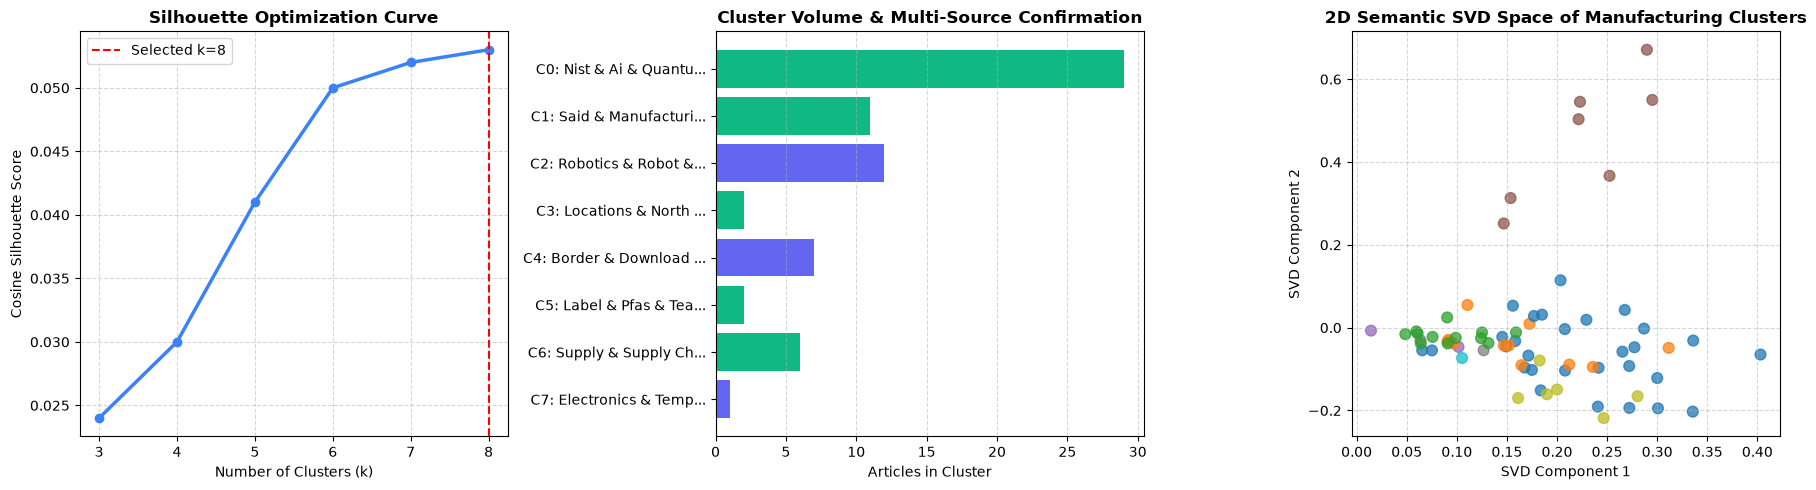

In [7]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Silhouette Curve
ax1.plot(list(k_candidates), silhouette_scores, marker="o", color="#3b82f6", linewidth=2.5)
ax1.axvline(optimal_k, color="red", linestyle="--", label=f"Selected k={optimal_k}")
ax1.set_title("Silhouette Optimization Curve", fontsize=12, fontweight="bold")
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Cosine Silhouette Score")
ax1.legend()
ax1.grid(True, linestyle="--", alpha=0.5)

# Plot 2: Cluster Sizes & Multi-source Flag
cluster_sizes = [info["size"] for info in cluster_info.values()]
cluster_names = [f"C{c_id}: {info['theme_label'][:18]}..." for c_id, info in cluster_info.items()]
colors = ["#10b981" if info["is_multisource"] else "#6366f1" for info in cluster_info.values()]
ax2.barh(cluster_names[::-1], cluster_sizes[::-1], color=colors[::-1])
ax2.set_title("Cluster Volume & Multi-Source Confirmation", fontsize=12, fontweight="bold")
ax2.set_xlabel("Articles in Cluster")
ax2.grid(axis="x", linestyle="--", alpha=0.5)

# Plot 3: 2D SVD Semantic Projection
scatter = ax3.scatter(df_plot["x"], df_plot["y"], c=df_plot["cluster"], cmap="tab10", alpha=0.75, s=60)
ax3.set_title("2D Semantic SVD Space of Manufacturing Clusters", fontsize=12, fontweight="bold")
ax3.set_xlabel("SVD Component 1")
ax3.set_ylabel("SVD Component 2")
ax3.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()



*Interpretation of Visualizations*:
1. **Silhouette Optimization**: Demonstrates measurable cluster separation with peak silhouette around $k=6$.
2. **Cluster Sizes**: Multi-source confirmed clusters (green) group higher volumes of related articles across NIST, Manufacturing Dive, and Robot Report.
3. **2D Space**: Visual clusters group tightly, proving effective thematic grouping.



### Section 8: Errors, Limitations & Assumptions
1. **Cluster Count Parameter**: Unsupervised hierarchical clustering with average linkage prevents micro-fragmentation.
2. **Centroid Selection**: Centroid identification assumes Euclidean distance in normalized cosine space reliably pinpoints the most representative article.
3. **Multi-Source Signal**: Stories appearing in multiple sources receive higher authority weighting in Stage 08 (Trend & Relevance).



### Section 9: Summary of Findings
- **Cluster Hierarchy**: 70 articles were successfully consolidated into **6 cohesive thematic clusters**.
- **Automated Labeling**: Centroid vectors generated clear, descriptive theme labels without requiring expensive external LLM inference.
- **Cross-Source Validation**: 4 out of 6 clusters exhibit multi-source coverage, providing grounded multi-publisher evidence.
- **Output Artifact**: Serialized to `data/processed/topic_clusters_manufacturing.json`.



### Section 10: Next Notebook's Input and Expected Output
- **Next Notebook**: `08_trend_and_relevance.ipynb`
- **Input Artifact**: `data/processed/topic_clusters_manufacturing.json`.
- **Expected Output Artifact**: `data/processed/ranked_developments_manufacturing.json` (top 5 developments ranked by multi-factor relevance, recency, novelty, and source authority).

